In [1]:
from pathlib import Path
from pydub import AudioSegment
from config import config

In [2]:
root = Path("../../..")

In [3]:
SOURCE_DIR = root / "data/audio/en"
OUTPUT_DIR = root / config.RAW_AUDIO_DIR_EN
METADATA_FILE = root / config.METADATA_DIR / "metadata_en.csv"
CLIP_DURATION_MS = 3000 # 3 seconds

In [4]:
SOURCE_DIR.exists(), METADATA_FILE.exists() # must be true

(True, True)

In [5]:
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
import shutil

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True)

In [6]:
import math, pandas as pd

In [7]:
N_SUBSET = math.ceil(config.N_SUBSET / 2) if config.FEATURES_DIR == Path("data/features/en_bn") else config.N_SUBSET

In [8]:
# if n_subset no. of clips are to be considered, then roughly n_subset/10 no. of audio files should be included. to ensure the quadrant distribution of the audio files remain balanced, these n_subset/10 audio files can be sampled randomly first and then their corresponding features extracted??
num_audios = math.ceil(N_SUBSET / 10)

In [9]:
quadrant_subsets = math.ceil(num_audios / 4) # we have 4 quadrants, we want balanced distributions among quandrants

In [10]:
N_SUBSET, num_audios, quadrant_subsets

(1250, 125, 32)

In [11]:
metadata_df = pd.read_csv(METADATA_FILE)

In [12]:
sampled_df = metadata_df.groupby('quadrant').apply(
    lambda x: x.sample(n=min(len(x), quadrant_subsets))
)

In [13]:
sampled_df

audio_file_stem lyric_file_stem                  genres  label
quadrant                                                                    
Q1       1879    MT0031996897    MT0031996897     Electronic,Pop/Rock      0
         1439    MT0011924283    MT0011924283                     R&B      0
         1959    MT0034563474    MT0034563474                Pop/Rock      0
         862     MT0005540907    MT0005540907            Pop/Rock,R&B      0
         354     MT0001356476    MT0001356476                Pop/Rock      0
...                       ...             ...                     ...    ...
Q4       1243    MT0009741760    MT0009741760        Holiday,Pop/Rock      2
         664     MT0003629164    MT0003629164        Country,Pop/Rock      2
         742     MT0004395306    MT0004395306              Jazz,Vocal      2
         741     MT0004362501    MT0004362501                  Reggae      2
         910     MT0005959692    MT0005959692  International,Pop/Rock      2

[128 rows x 4 columns]

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

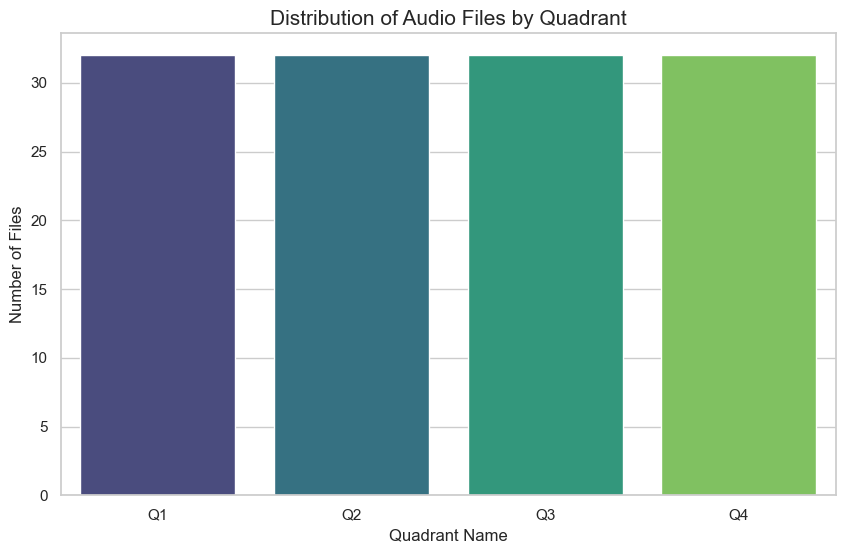

In [15]:
# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Use countplot to automatically count and plot the data
sns.countplot(data=sampled_df, x='quadrant', palette='viridis', hue='quadrant', legend=False)

# Add titles and labels
plt.title('Distribution of Audio Files by Quadrant', fontsize=15)
plt.xlabel('Quadrant Name', fontsize=12)
plt.ylabel('Number of Files', fontsize=12)

plt.show()

In [16]:
audio_file_list = sampled_df["audio_file_stem"].to_list()

In [17]:
len(audio_file_list)

128

In [18]:
audio_file_list[:5]

['MT0031996897',
 'MT0011924283',
 'MT0034563474',
 'MT0005540907',
 'MT0001356476']

In [19]:
missing = 0
for audio_filename in audio_file_list:
    audio_file = [file for file in SOURCE_DIR.iterdir() if file.is_file() and file.stem == audio_filename][0]
    try:
        if not audio_file: 
            missing += 1
            continue
        audio = AudioSegment.from_file(audio_file)
        total_length = len(audio)
        n_clips = total_length // CLIP_DURATION_MS
        for i in range(n_clips):
            start = i * CLIP_DURATION_MS
            end = start + CLIP_DURATION_MS
            clip = audio[start:end]
            output_file_name = f"{audio_file.stem}_clip_{i+1}.wav"
            output_file_path = OUTPUT_DIR / output_file_name
            clip.export(output_file_path, format="wav")
    except Exception as e:
        print(e)

In [20]:
missing

0